# Advanced Analytics

## Objectives

- Historical VaR (95%)
- Conditional VaR (CVaR)
- Rolling 90-Day Sharpe Ratio
- Investor Cohort Analysis
- SIP Continuity Analysis
- Fund Recommendation System
- Sector HHI Concentration
- Advanced Business Insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("ggplot")

In [2]:
# Project Path
BASE_DIR = Path.cwd().parent

RAW_DATA = BASE_DIR / "data" / "raw"

print(BASE_DIR)
print(RAW_DATA)

c:\Users\PRABHASH\Desktop\Mutual_Fund_Analytics
c:\Users\PRABHASH\Desktop\Mutual_Fund_Analytics\data\raw


In [3]:
fund_master = pd.read_csv(RAW_DATA / "01_fund_master.csv")
nav_history = pd.read_csv(RAW_DATA / "02_nav_history.csv")
transactions = pd.read_csv(RAW_DATA / "08_investor_transactions.csv")
holdings = pd.read_csv(RAW_DATA / "09_portfolio_holdings.csv")

print("Fund Master Shape :", fund_master.shape)
print("NAV History Shape :", nav_history.shape)
print("Transactions Shape :", transactions.shape)
print("Holdings Shape :", holdings.shape)

Fund Master Shape : (40, 15)
NAV History Shape : (46000, 3)
Transactions Shape : (32778, 13)
Holdings Shape : (322, 8)


In [4]:
nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [5]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

nav_history = nav_history.sort_values(
    by=["amfi_code", "date"]
)

nav_history.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [6]:
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [7]:
risk_metrics = []

for amfi_code, group in nav_history.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    # Historical VaR (95%)
    var95 = np.percentile(returns, 5)

    # Conditional VaR (CVaR)
    cvar95 = returns[returns <= var95].mean()

    risk_metrics.append({
        "amfi_code": amfi_code,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

risk_df = pd.DataFrame(risk_metrics)

risk_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [8]:
risk_df = risk_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

risk_df = risk_df[
    ["amfi_code", "scheme_name", "VaR_95", "CVaR_95"]
]

risk_df.head()

,amfi_code,scheme_name,VaR_95,CVaR_95
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.014364,-0.018060
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.003793,-0.004994
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459


In [9]:
risk_df.to_csv(
    BASE_DIR / "reports" / "var_cvar_report.csv",
    index=False
)

print("✅ var_cvar_report.csv saved successfully!")

✅ var_cvar_report.csv saved successfully!


## Task 2: Rolling 90-Day Sharpe Ratio

In [10]:
key_funds = [
    119551,
    120503,
    118632,
    119092,
    120841
]

selected_nav = nav_history[
    nav_history["amfi_code"].isin(key_funds)
].copy()

selected_nav.head()

,amfi_code,date,nav,daily_return
17250,118632,2022-01-03,42.8339,NaN
17251,118632,2022-01-04,42.8033,-0.000714
17252,118632,2022-01-05,43.0564,0.005913
17253,118632,2022-01-06,43.2088,0.003540
17254,118632,2022-01-07,42.9585,-0.005793


In [11]:
selected_nav["rolling_sharpe"] = (
    selected_nav.groupby("amfi_code")["daily_return"]
    .transform(
        lambda x: (
            x.rolling(window=90).mean()
            / x.rolling(window=90).std()
        ) * np.sqrt(252)
    )
)

selected_nav.head(100)

,amfi_code,date,nav,daily_return,rolling_sharpe
17250,118632,2022-01-03,42.8339,NaN,NaN
17251,118632,2022-01-04,42.8033,-0.000714,NaN
17252,118632,2022-01-05,43.0564,0.005913,NaN
17253,118632,2022-01-06,43.2088,0.003540,NaN
17254,118632,2022-01-07,42.9585,-0.005793,NaN
...,...,...,...,...,...
17345,118632,2022-05-16,54.1180,-0.002189,4.572137
17346,118632,2022-05-17,53.8519,-0.004917,4.632987
17347,118632,2022-05-18,54.2127,0.006700,4.757113
17348,118632,2022-05-19,54.6482,0.008033,4.786752


In [12]:
selected_nav = selected_nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

selected_nav.head()

,amfi_code,date,nav,daily_return,rolling_sharpe,scheme_name
0,118632,2022-01-03,42.8339,NaN,NaN,Nippon India Large Cap Fund - Regular - Growth
1,118632,2022-01-04,42.8033,-0.000714,NaN,Nippon India Large Cap Fund - Regular - Growth
2,118632,2022-01-05,43.0564,0.005913,NaN,Nippon India Large Cap Fund - Regular - Growth
3,118632,2022-01-06,43.2088,0.003540,NaN,Nippon India Large Cap Fund - Regular - Growth
4,118632,2022-01-07,42.9585,-0.005793,NaN,Nippon India Large Cap Fund - Regular - Growth


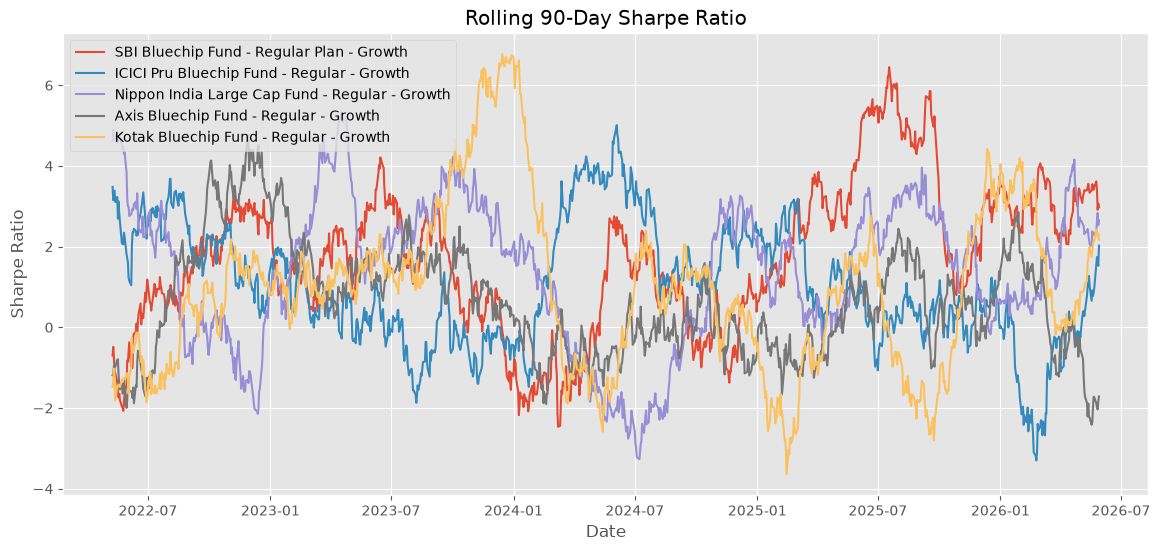

✅ rolling_sharpe_chart.png saved successfully!


In [13]:
plt.figure(figsize=(14,6))

for code in key_funds:
    temp = selected_nav[selected_nav["amfi_code"] == code]

    if not temp.empty:
        plt.plot(
            temp["date"],
            temp["rolling_sharpe"],
            label=temp["scheme_name"].iloc[0]
        )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig(
    BASE_DIR / "reports" / "rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ rolling_sharpe_chart.png saved successfully!")

## Task 3: Investor Cohort Analysis

In [14]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [15]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

### Step 1: Identify First Transaction Year

In [16]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

first_txn = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [17]:
avg_sip = (
    transactions[
        transactions["transaction_type"] == "SIP"
    ]
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="avg_sip_amount")
)

avg_sip

KeyError: 'cohort_year'

In [18]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [19]:
first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [20]:
transactions = transactions.merge(
    first_txn[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [21]:
avg_sip = (
    transactions[
        transactions["transaction_type"] == "SIP"
    ]
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="avg_sip_amount")
)

avg_sip

,cohort_year,avg_sip_amount
0,2024,10996.885825
1,2025,13505.209581


In [22]:
total_invested = (
    transactions
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested")
)

total_invested

,cohort_year,total_invested
0,2024,3491125187
1,2025,30455243


In [23]:
top_fund = (
    transactions
    .groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="count")
)

top_fund = (
    top_fund
    .sort_values(
        ["cohort_year", "count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)

top_fund = top_fund.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

top_fund

,cohort_year,amfi_code,count,scheme_name
0,2024,148568,874,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,119599,12,SBI Small Cap Fund - Direct Plan - Growth


In [24]:
cohort_summary = (
    avg_sip
    .merge(total_invested, on="cohort_year")
    .merge(
        top_fund[
            ["cohort_year", "scheme_name"]
        ],
        on="cohort_year"
    )
)

cohort_summary

,cohort_year,avg_sip_amount,total_invested,scheme_name
0,2024,10996.885825,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,13505.209581,30455243,SBI Small Cap Fund - Direct Plan - Growth


## Task 4: SIP Continuity Analysis

In [26]:
sip_txn = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

sip_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [27]:
sip_txn["transaction_date"] = pd.to_datetime(
    sip_txn["transaction_date"]
)

sip_txn = sip_txn.sort_values(
    by=["investor_id", "transaction_date"]
)

sip_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024


In [28]:
sip_count = (
    sip_txn
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

sip_count.sort_values(
    by="sip_count",
    ascending=False
).head(10)

,investor_id,sip_count
3962,INV004154,12
586,INV000612,11
4223,INV004427,11
1597,INV001673,11
649,INV000676,11
1674,INV001753,11
4093,INV004289,11
3479,INV003650,11
2581,INV002712,11
4206,INV004410,11


In [29]:
eligible_investors = sip_count[
    sip_count["sip_count"] >= 6
]

eligible_investors.head()

,investor_id,sip_count
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8


In [30]:
sip_txn = sip_txn.merge(
    eligible_investors[["investor_id"]],
    on="investor_id",
    how="inner"
)

print("Eligible Investors:", sip_txn["investor_id"].nunique())

sip_txn.head()

Eligible Investors: 1362


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024
1,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024
2,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024
3,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024
4,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024


In [31]:
sip_txn["gap_days"] = (
    sip_txn
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_txn.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
0,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
1,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
2,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0
3,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,59.0
4,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,265.0
5,INV000004,2025-05-17,119599,SIP,2110,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,49.0
6,INV000008,2024-05-27,101206,SIP,8061,Punjab,Amritsar,B30,26-35,Female,18.6,Cheque,Verified,2024,NaN
7,INV000008,2024-06-23,102887,SIP,55850,Punjab,Amritsar,B30,26-35,Female,18.6,Net Banking,Verified,2024,27.0
8,INV000008,2024-12-05,100025,SIP,425,Punjab,Amritsar,B30,26-35,Female,18.6,UPI,Verified,2024,165.0
9,INV000008,2025-01-18,119552,SIP,458,Punjab,Amritsar,B30,26-35,Female,18.6,Cheque,Verified,2024,44.0


In [32]:
sip_gap = (
    sip_txn
    .groupby("investor_id")["gap_days"]
    .mean()
    .reset_index(name="avg_gap_days")
)

sip_gap.head()

,investor_id,avg_gap_days
0,INV000004,85.400000
1,INV000008,70.400000
2,INV000010,64.800000
3,INV000011,40.166667
4,INV000012,57.000000


In [33]:
sip_gap["status"] = np.where(
    sip_gap["avg_gap_days"] > 35,
    "At Risk",
    "Healthy"
)

sip_gap.head()

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [34]:
sip_gap["status"].value_counts()

status
At Risk    1332
Healthy      30
Name: count, dtype: int64

### Business Insight

Out of 1,362 eligible investors (with 6 or more SIP transactions):

- **1,332 investors** were classified as **At Risk** because their average SIP gap exceeded 35 days.
- **30 investors** maintained an average SIP gap of 35 days or less and were classified as **Healthy**.

This indicates that a large proportion of investors have irregular SIP contributions. Asset Management Companies (AMCs) can use this analysis to identify investors who may require reminders, personalized engagement, or retention campaigns to improve SIP continuity.

## Task 5: Simple Fund Recommender

In [35]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

In [37]:
performance = pd.read_csv(
    RAW_DATA / "07_scheme_performance.csv"
)

print("Performance Shape:", performance.shape)
performance.head()

Performance Shape: (40, 19)


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [38]:
risk_appetite = "Moderate"   # Change to Low, Moderate, High, Very High

print("Selected Risk:", risk_appetite)

Selected Risk: Moderate


In [39]:
recommended = (
    performance[
        performance["risk_grade"] == risk_appetite
    ]
    .sort_values(
        by="sharpe_ratio",
        ascending=False
    )
)

recommended.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,0.97,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,0.96,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,1.03,1.03,1.27,14.0,-26.59,41553,0.80,3,Moderate
15,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Large Cap,Regular,15.84,14.00,14.70,13.14,0.86,0.88,1.00,1.68,14.0,-16.07,20909,1.51,4,Moderate
28,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Large Cap,Regular,14.82,13.78,12.86,12.44,1.34,1.03,0.98,1.25,14.0,-15.07,23500,1.60,5,Moderate


In [40]:
top3 = recommended[
    [
        "scheme_name",
        "fund_house",
        "risk_grade",
        "sharpe_ratio",
        "return_3yr_pct",
        "expense_ratio_pct",
        "morningstar_rating"
    ]
].head(3)

top3

,scheme_name,fund_house,risk_grade,sharpe_ratio,return_3yr_pct,expense_ratio_pct,morningstar_rating
5,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Moderate,1.06,14.84,1.55,5
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Moderate,1.06,14.81,1.46,5
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Moderate,1.03,14.41,0.80,3


### Business Insight

The recommender filters funds based on the investor's selected risk appetite and ranks them using the Sharpe Ratio.

For **Moderate** risk investors, the recommended funds are:

1. HDFC Top 100 Fund - Regular Plan - Growth
2. Mirae Asset Large Cap Fund - Regular - Growth
3. ICICI Pru Bluechip Fund - Direct - Growth

These funds provide the highest risk-adjusted returns within the selected risk category.

## Task 6: Sector HHI Concentration

In [41]:
holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [42]:
# Calculate HHI for each fund
hhi = (
    holdings
    .groupby("amfi_code")["weight_pct"]
    .apply(lambda x: (x / 100).pow(2).sum())
    .reset_index(name="HHI")
)

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [43]:
hhi = hhi.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

hhi.head()

,amfi_code,HHI,scheme_name
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth


In [44]:
hhi = hhi.sort_values(
    by="HHI",
    ascending=False
)

hhi.head(10)

,amfi_code,HHI,scheme_name
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth


# Advanced Business Insights

### 1. Historical VaR (95%) Analysis
Historical VaR and CVaR analysis showed that some mutual funds are exposed to higher downside risk during adverse market conditions. Funds with more negative VaR values require careful risk monitoring.

### 2. Rolling Sharpe Ratio
The Rolling 90-Day Sharpe Ratio demonstrated changes in risk-adjusted performance over time. Funds maintaining consistently higher Sharpe Ratios delivered better returns relative to the risk taken.

### 3. Investor Cohort Analysis
The 2024 investor cohort contributed the highest overall investment, while the 2025 cohort showed a higher average SIP amount. This highlights differences in investment behaviour between investor groups.

### 4. SIP Continuity Analysis
Among investors with at least six SIP transactions, **1,332 investors were classified as At Risk**, while only **30 investors were Healthy**. This suggests that many investors have irregular SIP contributions and may benefit from reminder campaigns or engagement initiatives.

### 5. Portfolio Concentration (HHI)
HHI analysis identified **Axis Bluechip Fund - Regular - Growth** as the most concentrated portfolio in the dataset. Investors seeking greater diversification may prefer funds with lower HHI values.